In [1]:
import numpy as np
import pandas as pd
import easygui
from collections import defaultdict
from tkinter import filedialog
import os
import copy
import re

In [170]:
sheet = pd.ExcelFile(files[0])
sheet = sheet.sheet_names[0]
load = []
date = []

In [204]:
files = easygui.fileopenbox(multiple=True)
for name in files:
    excel = pd.read_excel(name, sheet_name = sheet)
    for x in excel.columns:
        if '-' in x:
            date.append(x.split('-')[1])
    excel = excel.iloc[:,10:16].drop(columns = [excel.columns[11],excel.columns[12], excel.columns[13],excel.columns[15]],
                                     axis = 1).drop(index = np.arange(0,4))
    lst1 = list(excel[excel[excel.columns[0]].isna() == True].index)
    lst2 = list(excel[excel[excel.columns[1]].isna() == True].index)
    lst = []
    for x in lst1:
        for y in lst2:
            if x == y:
                lst.append(x)
    excel = excel.drop(index = lst)
    load.append(excel.iloc[-1,1])

In [299]:
payload = pd.DataFrame(data = {'date':date, 'load':load})
payload.loc[121, 'date'] = '01.08.2025'
#payload['date'] = payload['date'].astype('datetime64[ns]')
payload['load'] = [round(float(x),2) for x in payload['load']]

In [250]:
payload

,date,load
0,01.06.15,9.74
1,28.02.15,10.00
2,30.04.15,10.02
3,30.06.15,10.38
4,30.09.15,15.28
...,...,...
121,01.08.2025,78.73
122,28.02.2025,79.25
123,30.04.2025,80.32
124,31.01.2025,79.53


In [300]:
newDate = []
for x in payload['date']:
    if len(x.split('.')[2]) > 2:
        newDate.append(x.split('.')[0] + '.' + x.split('.')[1] + '.' + x.split('.')[2])
    else:
        newDate.append(x.split('.')[0] + '.' + x.split('.')[1] + '.' + f'{int(x.split('.')[2])+2000}')

In [264]:
from datetime import datetime

format_code = "%Y-%m"
datetime_object = [datetime.strptime(x, format_code) for x in newDate]

In [265]:
datetime_object

[datetime.datetime(2015, 6, 1, 0, 0),
 datetime.datetime(2015, 2, 1, 0, 0),
 datetime.datetime(2015, 4, 1, 0, 0),
 datetime.datetime(2015, 6, 1, 0, 0),
 datetime.datetime(2015, 9, 1, 0, 0),
 datetime.datetime(2015, 11, 1, 0, 0),
 datetime.datetime(2015, 1, 1, 0, 0),
 datetime.datetime(2015, 3, 1, 0, 0),
 datetime.datetime(2015, 8, 1, 0, 0),
 datetime.datetime(2015, 10, 1, 0, 0),
 datetime.datetime(2015, 12, 1, 0, 0),
 datetime.datetime(2015, 8, 1, 0, 0),
 datetime.datetime(2016, 2, 1, 0, 0),
 datetime.datetime(2016, 4, 1, 0, 0),
 datetime.datetime(2016, 6, 1, 0, 0),
 datetime.datetime(2016, 9, 1, 0, 0),
 datetime.datetime(2016, 11, 1, 0, 0),
 datetime.datetime(2016, 3, 1, 0, 0),
 datetime.datetime(2016, 5, 1, 0, 0),
 datetime.datetime(2016, 7, 1, 0, 0),
 datetime.datetime(2016, 8, 1, 0, 0),
 datetime.datetime(2016, 10, 1, 0, 0),
 datetime.datetime(2015, 12, 1, 0, 0),
 datetime.datetime(2016, 12, 1, 0, 0),
 datetime.datetime(2017, 2, 1, 0, 0),
 datetime.datetime(2017, 4, 1, 0, 0),
 date

In [274]:
pd.date_range(start='2015-01', end='2025-10', freq='MS')

DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01',
               ...
               '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01'],
              dtype='datetime64[ns]', length=130, freq='MS')

In [301]:
payload['date'] =  newDate#[x.strftime('%Y-%B') for x in datetime_object]

In [302]:
payload.to_excel('payload.xlsx')

### reading payload excel

In [315]:
payload = pd.read_excel('payload.xlsx')
payload.drop(columns = [payload.columns[0]], axis = 1, inplace = True)
payload['date'] = [x.strftime('%Y-%B') for x in payload['date']]

In [318]:
payload.to_csv('payload.csv', index = False)

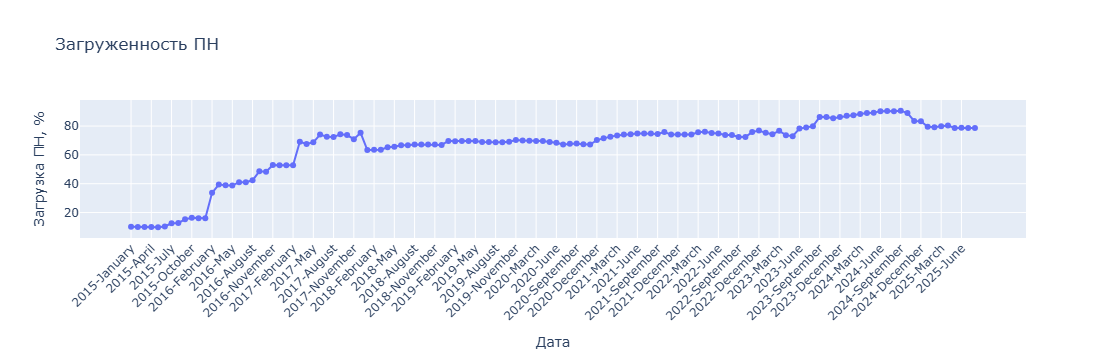

In [327]:
import plotly.graph_objects as go
import plotly.express as px
fig = go.Figure()
fig.add_trace(go.Scatter(x = payload['date'], y = payload['load'], mode = 'lines + markers'))
fig.update_layout(title = 'Загруженность ПН')
fig.update_xaxes(title_text="Дата", tickangle=-45)  
fig.update_yaxes(title_text="Загрузка ПН, %")  

In [328]:
fig.write_html('Payload.html')

In [343]:
csv = pd.read_csv('payload.csv')

In [344]:
csv['month'] = [x.strftime('%B') for x in csv['date'].astype('datetime64[ns]')]
csv = csv[(csv['month'] == 'June')|(csv['month'] == 'December')].reset_index(drop=True)
csv['season'] = ['winter' if 'December' in x else 'summer' for x in csv['month']]
csv['date'] = [x.strftime('%Y') for x in csv['date'].astype('datetime64[ns]')]

In [345]:
csv.drop(columns = ['month'], axis = 1, inplace = True)
csv.rename(columns = {'load' : 'max'}, inplace = True)

In [347]:
csv.to_csv('data for ML\\-payload-.csv')

# All payload data parser

In [200]:
datelist = list(np.arange(2015,2026,1))

In [233]:
for i in datelist:
    root_dir = f'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\{i}'
    all_files = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            # Сформируйте полный путь к файлу
            full_path = os.path.join(dirpath, filename)
            all_files.append(full_path)
    
    sheet = pd.ExcelFile(all_files[0])
    sheet = sheet.sheet_names[0]
    load = []
    date = []
    for name in all_files:
        excel = pd.read_excel(name, sheet_name = sheet)
        date.append([x for x in list(excel.columns) if '-' in x][0].split('-')[1])
        row = [x for x in range(len(excel.index)) if 'B12' in list(excel.iloc[x])][0]
        column = list(excel.iloc[row]).index('B12')+4
        load.append(excel.iloc[[row+2],column].values[0])
    
    payload = pd.DataFrame(data = np.array([date, load]).T, columns = ['date', 'max'])
    newDate = []
    for x in payload['date']:
        if len(x.split('.')[2]) > 2:
            newDate.append(x.split('.')[0] + '.' + x.split('.')[1] + '.' + x.split('.')[2])
        else:
            newDate.append(x.split('.')[0] + '.' + x.split('.')[1] + '.' + f'{int(x.split('.')[2])+2000}')
    payload['date'] = newDate
    payload['date'] = pd.to_datetime(payload['date'], dayfirst=True)
    payload.sort_values('date', inplace = True)
    payload = payload.reset_index().drop(columns = 'index', axis = 1)
    payload['max'] = [round(x,2) for x in payload['max'].astype('float')]
    
    excel_file = 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\payload.xlsx'
    writer = pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='overlay')
    payload.to_excel(writer, sheet_name=f'{i}', index=False) 
    writer.close()

In [227]:
payload

,date,max
0,02.01.15,9.313271604938272
1,03.01.15,9.313271604938272
2,04.01.15,9.313271604938272
3,05.01.15,9.313271604938272
4,06.01.15,9.837962962962964
...,...,...
360,28.12.15,16.040123456790123
361,29.12.15,16.040123456790123
362,30.12.15,16.040123456790123
363,31.12.15,16.040123456790123


In [228]:
all_files

['C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\2015\\01_Январь\\01-02.01.15 Прилож. к отчету.xls',
 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\2015\\01_Январь\\02-03.01.15 Прилож. к отчету.xls',
 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\2015\\01_Январь\\03-04.01.15 Прилож. к отчету.xls',
 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\2015\\01_Январь\\04-05.01.15 Прилож. к отчету.xls',
 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\2015\\01_Январь\\05-06.01.15 Прилож. к отчету.xls',
 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\2015\\01_Январь\\06-07.01.15 Прилож. к